In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:

gcs_path = '../data/House Price Prediction Dataset.csv'

# Load the CSV directly from GCS
df = pd.read_csv(gcs_path)
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec

def create_visualizations(df):
    # Set seaborn style properly
    sns.set_theme(style="whitegrid")
    
    # Define a consistent color palette with light green tones
    colors = {
        'primary': '#7CB342',      # Main green
        'secondary': '#AED581',    # Light green
        'accent': '#C5E1A5',       # Very light green
        'highlight': '#33691E',    # Dark green for highlights/trend lines
        'background': '#F1F8E9'    # Super light green background
    }
    
    # Create figure
    fig = plt.figure(figsize=(20, 15))
    gs = GridSpec(3, 2, figure=fig)
    fig.patch.set_facecolor(colors['background'])
    
    # 1. Price Distribution
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_facecolor(colors['background'])
    sns.histplot(data=df, x='Price', bins=30, 
                color=colors['primary'], 
                alpha=0.8,
                ax=ax1)
    ax1.set_title('House Price Distribution', fontsize=14, pad=15)
    ax1.set_xlabel('Price ($)', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.xaxis.set_major_formatter(lambda x, p: f'${x/1e6:.1f}M')
    
    # 2. Price vs Area Scatter
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_facecolor(colors['background'])
    sns.scatterplot(data=df, x='Area', y='Price',
                   color=colors['primary'],
                   alpha=0.6,
                   ax=ax2)
    
    # Add trend line
    z = np.polyfit(df['Area'], df['Price'], 1)
    p = np.poly1d(z)
    ax2.plot(df['Area'], p(df['Area']), 
             color=colors['highlight'], 
             linestyle='--', 
             alpha=0.8,
             linewidth=2)
    
    ax2.set_title('Price vs Area with Trend Line', fontsize=14, pad=15)
    ax2.set_xlabel('Area (sq ft)', fontsize=12)
    ax2.set_ylabel('Price ($)', fontsize=12)
    ax2.yaxis.set_major_formatter(lambda x, p: f'${x/1e6:.1f}M')
    
    # 3. Average Price by Location
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.set_facecolor(colors['background'])
    
    location_stats = df.groupby('Location')['Price'].agg(['mean', 'std', 'count'])
    location_stats = location_stats.sort_values('mean', ascending=True)
    
    yerr = location_stats['std'] / np.sqrt(location_stats['count'])
    
    sns.barplot(x=location_stats['mean'], 
                y=location_stats.index,
                color=colors['primary'],
                alpha=0.8,
                ax=ax3)
    
    ax3.set_title('Average Price by Location', fontsize=14, pad=15)
    ax3.set_xlabel('Average Price ($)', fontsize=12)
    ax3.xaxis.set_major_formatter(lambda x, p: f'${x/1e6:.1f}M')
    
    # 4. Price Distribution by Condition
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.set_facecolor(colors['background'])
    
    sns.boxplot(x='Condition', y='Price', 
                data=df, 
                ax=ax4,
                color=colors['primary'],
                saturation=0.7)
    
    ax4.set_title('Price Distribution by Condition', fontsize=14, pad=15)
    ax4.set_ylabel('Price ($)', fontsize=12)
    ax4.yaxis.set_major_formatter(lambda x, p: f'${x/1e6:.1f}M')
    
    # 5. Correlation Heatmap
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.set_facecolor(colors['background'])
    
    numerical_cols = ['Price', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
    correlation_matrix = df[numerical_cols].corr()
    
    sns.heatmap(correlation_matrix,
                annot=True,
                cmap='BuGn',  # Green color map
                center=0,
                ax=ax5,
                fmt='.2f',
                square=True)
    
    ax5.set_title('Correlation Heatmap', fontsize=14, pad=15)
    ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45)
    
    # 6. Price by Number of Bedrooms
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.set_facecolor(colors['background'])
    
    sns.boxplot(x='Bedrooms', y='Price', 
                data=df,
                ax=ax6,
                color=colors['primary'],
                saturation=0.7)
    
    ax6.set_title('Price Distribution by Number of Bedrooms', fontsize=14, pad=15)
    ax6.set_xlabel('Number of Bedrooms', fontsize=12)
    ax6.set_ylabel('Price ($)', fontsize=12)
    ax6.yaxis.set_major_formatter(lambda x, p: f'${x/1e6:.1f}M')
    
    # Adjust layout and spacing
    plt.tight_layout()
    
    return fig

# To use the function:
# fig = create_visualizations(df)
# plt.show()

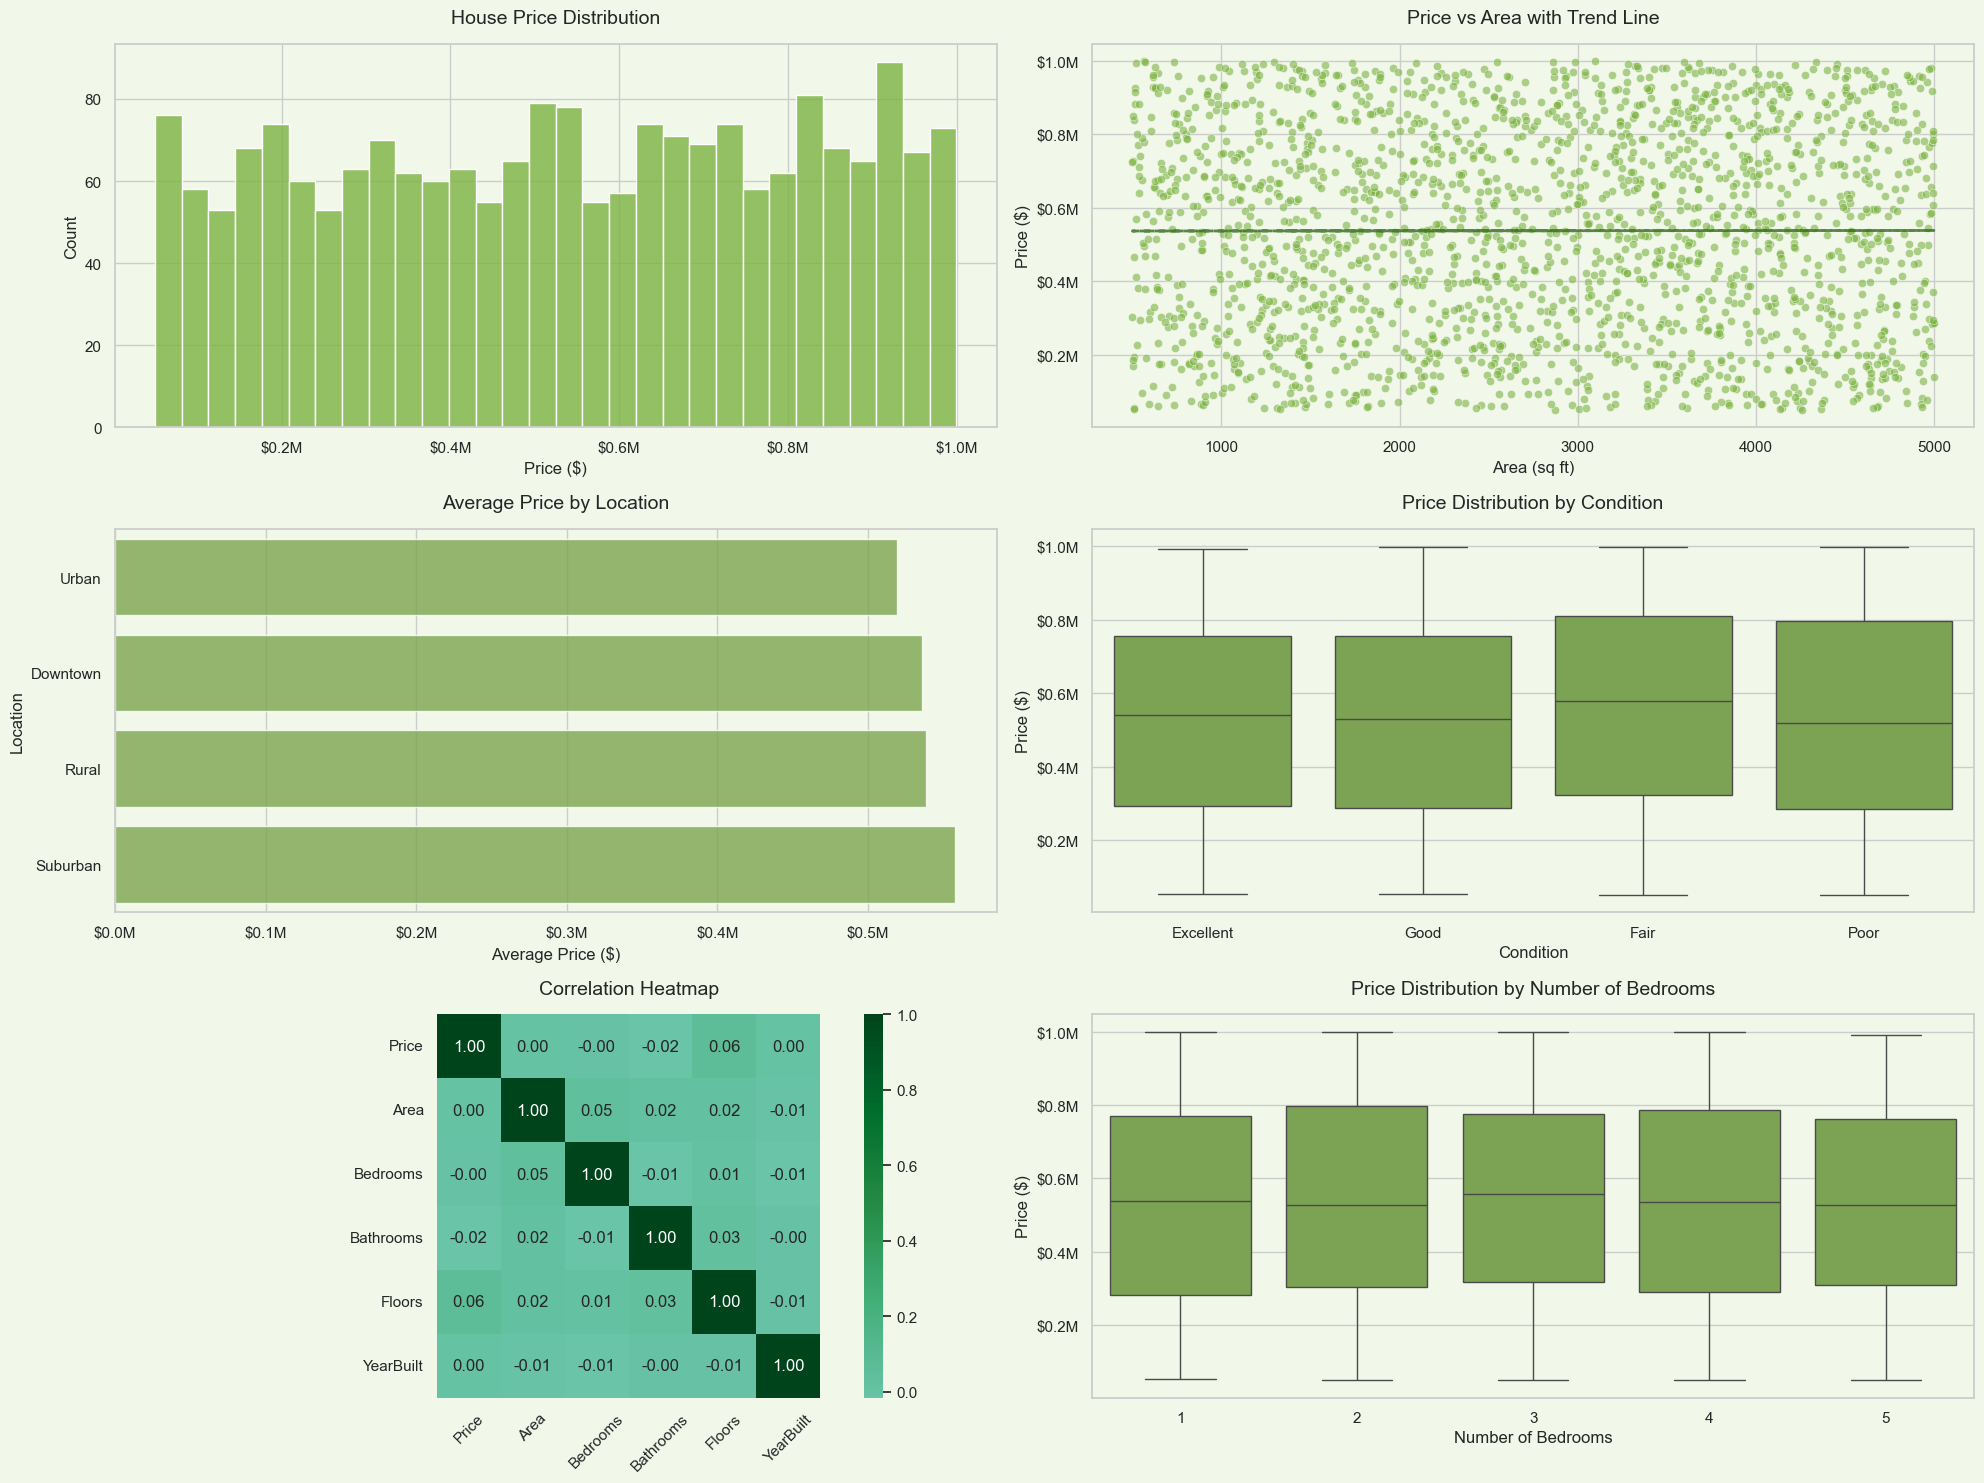

In [8]:
# To use the function:
fig = create_visualizations(df)
plt.show()

In [11]:


def format_currency(value):
    """Format large numbers as currency with M/K suffix"""
    if value >= 1000000:
        return f"${value/1000000:.2f}M"
    elif value >= 1000:
        return f"${value/1000:.1f}K"
    else:
        return f"${value:.2f}"

def analyze_house_data(df):
    print("="*50)
    print("HOUSE PRICE DATASET ANALYSIS REPORT")
    print("="*50)
    
    # 1. Basic Dataset Information
    print("\n1. DATASET OVERVIEW")
    print("-"*30)
    print(f"Total number of properties: {len(df):,}")
    print(f"Number of features: {len(df.columns)}")
    print("\nFeatures in dataset:")
    for col in df.columns:
        print(f"- {col}: {df[col].dtype}")
    
    # 2. Price Analysis
    print("\n2. PRICE ANALYSIS")
    print("-"*30)
    price_stats = df['Price'].describe()
    print(f"Price Range: {format_currency(price_stats['min'])} to {format_currency(price_stats['max'])}")
    print(f"Mean Price: {format_currency(price_stats['mean'])}")
    print(f"Median Price: {format_currency(price_stats['50%'])}")
    print(f"Price Standard Deviation: {format_currency(price_stats['std'])}")
    
    # Calculate price quartiles
    q1, q3 = df['Price'].quantile([0.25, 0.75])
    print(f"\nPrice Quartiles:")
    print(f"- 25th percentile: {format_currency(q1)}")
    print(f"- 75th percentile: {format_currency(q3)}")
    
    # 3. Location Analysis
    print("\n3. LOCATION ANALYSIS")
    print("-"*30)
    location_stats = df.groupby('Location').agg({
        'Price': ['count', 'mean', 'median', 'std']
    })
    
    print("Price statistics by location:")
    for location in location_stats.index:
        stats = location_stats.loc[location, 'Price']
        print(f"\n{location}:")
        print(f"- Number of properties: {stats['count']:,}")
        print(f"- Average price: {format_currency(stats['mean'])}")
        print(f"- Median price: {format_currency(stats['median'])}")
        print(f"- Price std dev: {format_currency(stats['std'])}")
    
    # 4. Property Characteristics
    print("\n4. PROPERTY CHARACTERISTICS")
    print("-"*30)
    print("\nBedrooms:")
    bedroom_stats = df['Bedrooms'].value_counts().sort_index()
    for beds, count in bedroom_stats.items():
        percentage = (count/len(df))*100
        print(f"- {beds} bedrooms: {count:,} properties ({percentage:.1f}%)")
        
    print("\nBathrooms:")
    bathroom_stats = df['Bathrooms'].value_counts().sort_index()
    for baths, count in bathroom_stats.items():
        percentage = (count/len(df))*100
        print(f"- {baths} bathrooms: {count:,} properties ({percentage:.1f}%)")
    
    # 5. Property Condition Analysis
    print("\n5. CONDITION ANALYSIS")
    print("-"*30)
    condition_stats = df.groupby('Condition').agg({
        'Price': ['count', 'mean', 'median'],
        'YearBuilt': 'mean'
    }).round(0)
    
    for condition in condition_stats.index:
        price_stats = condition_stats.loc[condition, 'Price']
        year_built = condition_stats.loc[condition, 'YearBuilt']
        print(f"\n{condition} Condition Properties:")
        print(f"- Count: {int(price_stats['count']):,}")
        print(f"- Average price: {format_currency(price_stats['mean'])}")
        print(f"- Median price: {format_currency(price_stats['median'])}")
        print(f"- Average year built: {int(year_built)}")
    
    # 6. Age and Price Relationship
    print("\n6. AGE AND PRICE RELATIONSHIP")
    print("-"*30)
    df['Age'] = 2024 - df['YearBuilt']
    age_correlation = df['Age'].corr(df['Price'])
    print(f"Correlation between age and price: {age_correlation:.3f}")
    
    # Group properties by decades
    df['Decade'] = (df['YearBuilt'] // 10) * 10
    decade_stats = df.groupby('Decade').agg({
        'Price': ['count', 'mean'],
        'YearBuilt': 'count'
    }).sort_index()
    
    print("\nPrice by construction decade:")
    for decade in decade_stats.index:
        stats = decade_stats.loc[decade]
        print(f"\n{decade}s:")
        print(f"- Number of properties: {int(stats['YearBuilt']):,}")
        print(f"- Average price: {format_currency(stats['Price']['mean'])}")
    
    # 7. Price per Square Foot Analysis
    print("\n7. PRICE PER SQUARE FOOT ANALYSIS")
    print("-"*30)
    df['Price_per_sqft'] = df['Price'] / df['Area']
    ppsf_stats = df['Price_per_sqft'].describe()
    
    print(f"Average price per sq ft: ${ppsf_stats['mean']:.2f}")
    print(f"Median price per sq ft: ${ppsf_stats['50%']:.2f}")
    print(f"Price per sq ft range: ${ppsf_stats['min']:.2f} to ${ppsf_stats['max']:.2f}")
    
    # 8. Key Insights
    print("\n8. KEY INSIGHTS")
    print("-"*30)
    print(f"1. Most expensive location: {df.groupby('Location')['Price'].mean().idxmax()}")
    print(f"2. Most common number of bedrooms: {int(df['Bedrooms'].mode().values[0])}")
    print(f"3. Average house age: {df['Age'].mean():.1f} years")
    print(f"4. Property with highest price per sq ft: ${df['Price_per_sqft'].max():.2f}/sq ft")
    print(f"5. Most common condition: {df['Condition'].mode().values[0]}")
    
    # 9. Correlation Analysis
    print("\n9. CORRELATION ANALYSIS")
    print("-"*30)
    numerical_cols = ['Price', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
    correlation_matrix = df[numerical_cols].corr()['Price'].sort_values(ascending=False)
    print("Correlation with Price:")
    for feature, corr in correlation_matrix.items():
        if feature != 'Price':
            print(f"- {feature}: {corr:.3f}")

# Run the analysis
analyze_house_data(df)

HOUSE PRICE DATASET ANALYSIS REPORT

1. DATASET OVERVIEW
------------------------------
Total number of properties: 2,000
Number of features: 13

Features in dataset:
- Id: int64
- Area: int64
- Bedrooms: int64
- Bathrooms: int64
- Floors: int64
- YearBuilt: int64
- Location: object
- Condition: object
- Garage: object
- Price: int64
- Age: int64
- Decade: int64
- Price_per_sqft: float64

2. PRICE ANALYSIS
------------------------------
Price Range: $50.0K to $999.7K
Mean Price: $537.7K
Median Price: $539.3K
Price Standard Deviation: $276.4K

Price Quartiles:
- 25th percentile: $300.1K
- 75th percentile: $780.1K

3. LOCATION ANALYSIS
------------------------------
Price statistics by location:

Downtown:
- Number of properties: 558.0
- Average price: $536.1K
- Median price: $532.3K
- Price std dev: $275.3K

Rural:
- Number of properties: 474.0
- Average price: $538.6K
- Median price: $527.6K
- Price std dev: $277.0K

Suburban:
- Number of properties: 483.0
- Average price: $557.4K
- Me

C:\Users\User\AppData\Local\Temp\ipykernel_10460\3914242514.py:85: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"- Average year built: {int(year_built)}")
C:\Users\User\AppData\Local\Temp\ipykernel_10460\3914242514.py:105: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"- Number of properties: {int(stats['YearBuilt']):,}")
